In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
print("All libraries loaded ✓")

# Load the CSV into a DataFrame (a table)
df = pd.read_csv("rainfall in india 1901-2015.csv")

# How many rows and columns?
print(f"Shape: {df.shape}")

# What do the first 5 rows look like?
df.head(5)
df.info()
print("\n--- Missing values per column ---")
print(df.isnull().sum())


All libraries loaded ✓
Shape: (4116, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17  Jun-Sep      4106 non-null   float64
 18  Oct-Dec

In [ ]:
kerala = df[df["SUBDIVISION"] == "KERALA"]
print(kerala.shape)



(115, 19)


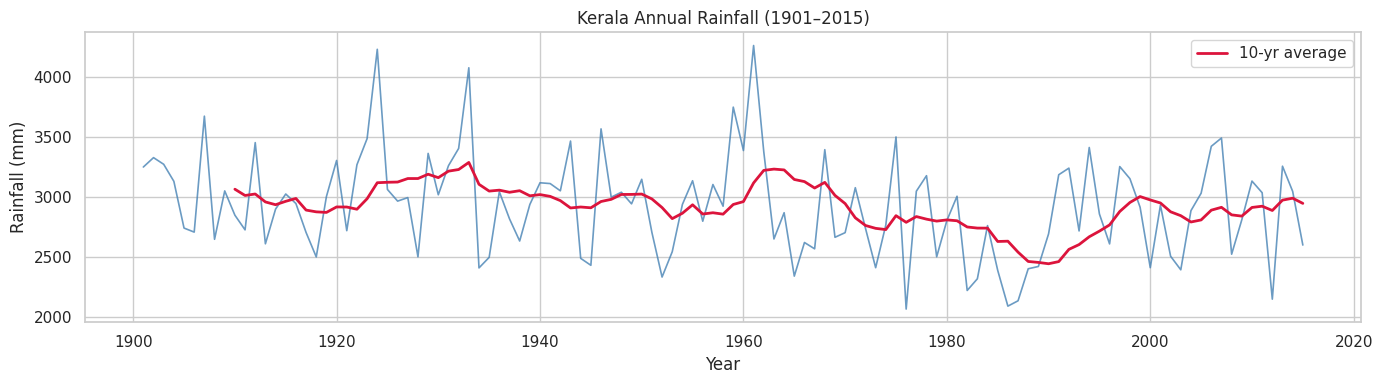

In [ ]:
#Annual Rainfall trend (both rough and corrected and rectified)
plt.figure(figsize=(14, 4))
plt.plot(kerala["YEAR"], kerala["ANNUAL"],
         color="steelblue", linewidth=1.2, alpha=0.8)
rolling_avg = kerala["ANNUAL"].rolling(window=10).mean()
plt.plot(kerala["YEAR"], rolling_avg,
         color="crimson", linewidth=2, label="10-yr average")

plt.title("Kerala Annual Rainfall (1901–2015)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

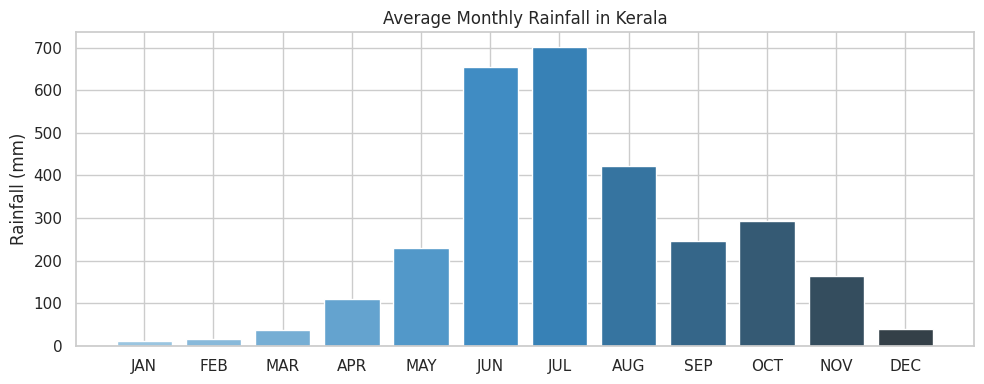


Top 3 rainiest months:
JUL    700.953043
JUN    654.302609
AUG    421.977391
dtype: float64


In [ ]:
#Monthly seasonality — the monsoon pattern

months = ["JAN","FEB","MAR","APR","MAY","JUN",
          "JUL","AUG","SEP","OCT","NOV","DEC"]

monthly_avg = kerala[months].mean()

plt.figure(figsize=(10, 4))
bars = plt.bar(months, monthly_avg,
               color=sns.color_palette("Blues_d", 12))
plt.title("Average Monthly Rainfall in Kerala")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

print("\nTop 3 rainiest months:")
print(monthly_avg.sort_values(ascending=False).head(3))

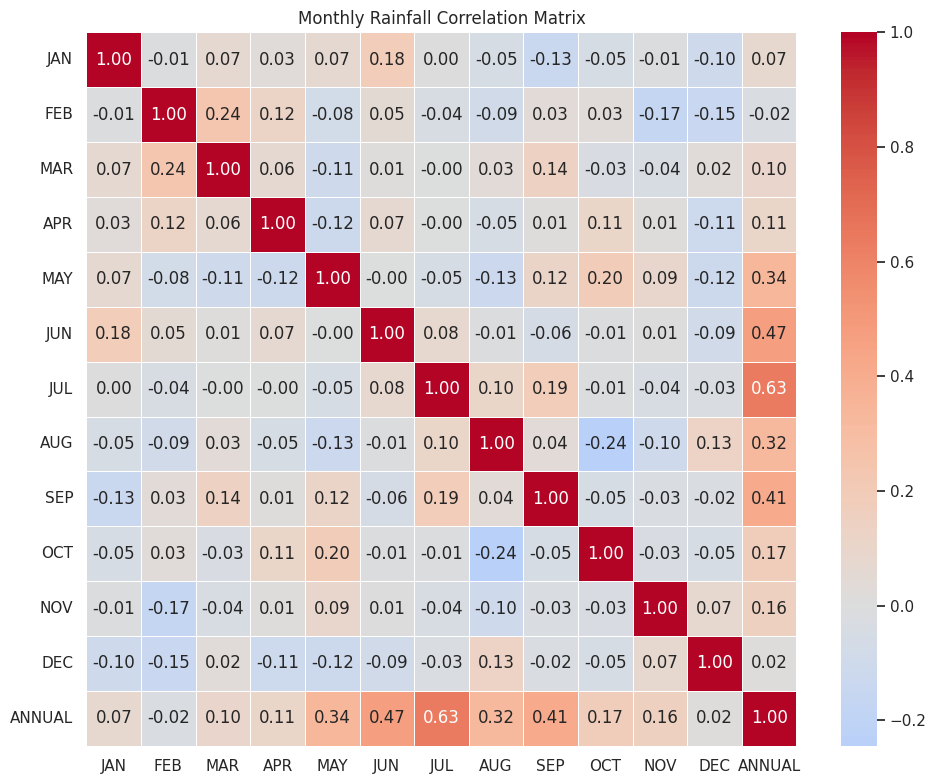

In [ ]:
# Correlation heatmap — which months move together?
corr = kerala[months + ["ANNUAL"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5)
plt.title("Monthly Rainfall Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Now to calculate the flood possibilties ,there are actually no flood variable or coln. So we engineer a code for it.

low_thresh = kerala["ANNUAL"].quantile(0.25)
high_thresh = kerala["ANNUAL"].quantile(0.75)

print(f"Low risk below:  {low_thresh:.1f} mm")
print(f"High risk above: {high_thresh:.1f} mm")

# Create the label column
def flood_risk(annual_rain):
    if annual_rain >= high_thresh:
        return "High"
    elif annual_rain >= low_thresh:
        return "Medium"
    else:
        return "Low"

kerala["FLOOD_RISK"] = kerala["ANNUAL"].apply(flood_risk)

# See the distribution
print("\nFlood risk distribution:")
print(kerala["FLOOD_RISK"].value_counts())

Low risk below:  2627.9 mm
High risk above: 3164.1 mm

Flood risk distribution:
FLOOD_RISK
Medium    57
High      29
Low       29
Name: count, dtype: int64


/tmp/ipykernel_3860/370701599.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kerala["FLOOD_RISK"] = kerala["ANNUAL"].apply(flood_risk)


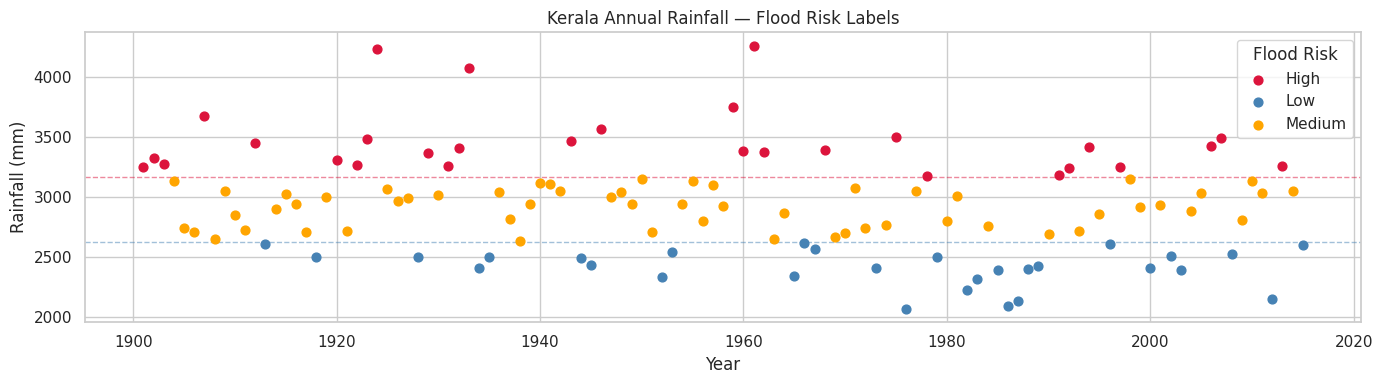

In [ ]:
# Colour-coded annual rainfall with risk bands
plt.figure(figsize=(14, 4))

colors = {"High": "crimson", "Medium": "orange", "Low": "steelblue"}
for risk, group in kerala.groupby("FLOOD_RISK"):
    plt.scatter(group["YEAR"], group["ANNUAL"],
                color=colors[risk], label=risk, zorder=3, s=40)

# Draw the threshold lines
plt.axhline(high_thresh, color="crimson", linestyle="--", alpha=0.5, linewidth=1)
plt.axhline(low_thresh,  color="steelblue", linestyle="--", alpha=0.5, linewidth=1)

plt.title("Kerala Annual Rainfall — Flood Risk Labels")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend(title="Flood Risk")
plt.tight_layout()
plt.show()

In [ ]:
# Save it — you'll load this in every future phase
kerala.to_csv("kerala_clean.csv", index=False)
print("Saved kerala_clean.csv ✓")
print(f"\nFinal dataset shape: {kerala.shape}")
print(f"Columns: {kerala.columns.tolist()}")

Saved kerala_clean.csv ✓

Final dataset shape: (115, 20)
Columns: ['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'FLOOD_RISK']
